<a href="https://colab.research.google.com/github/mehrerm/TFM/blob/main/notebooks/analisis_3Nolineal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

En este notebook se trabajará con el dataset ya depurado listo, se conservarán todas las librerías importadas utilizadas durante el EDA y los que se consideren necesarios.

In [1]:
#Cargo o importo pandas, numpy, Matplotlib,
import pandas as pd
import numpy as np

from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf


from scipy import stats





import requests
import unicodedata
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from statsmodels.regression.mixed_linear_model import MixedLM
!pip install optbinning
from optbinning import OptimalBinning, Scorecard, BinningProcess
from sklearn.linear_model import LogisticRegression
from urllib.parse import quote


#lugar donde se van guardando las figuras
fig_dir = "figuras"
os.makedirs(fig_dir, exist_ok=True)

table_dir = "tablas"
os.makedirs(table_dir, exist_ok=True)


#la url donde están los datos

BASE_URL = "https://raw.githubusercontent.com/mehrerm/TFM/main/data/processed/"
#########################

In [2]:
!git clone https://github.com/mehrerm/TFM.git


fatal: destination path 'TFM' already exists and is not an empty directory.


In [3]:
#df_merged = pd.read_csv("TFM/data/processed/df_merged.csv")
df_merged = pd.read_csv(BASE_URL + "df_merged.csv")
df = df_merged.copy()
df_merged.head()


,Cancer label,Sex,Type,Year,ASR (World),Crude rate,Cumulative risk,Total,Country_harmonized,Region Name,RTCenters,Linac,Protontherapy,XRay,Brachytherapy,Last Update,Population,Population_male,Population_female,GDP_per_capita
0,Lung,Male,Incidence,2007,61.434111,80.958928,7.865065,3666,Belarus,Eastern Europe,13,31,0,11,17,2024,9563133.0,4450421.0,5112713.0,4735.481076
1,Lung,Male,Incidence,2008,62.729974,84.930604,8.033257,3765,Belarus,Eastern Europe,13,31,0,11,17,2024,9529358.0,4432534.0,5096824.0,6376.175692
2,Lung,Male,Incidence,2009,61.098990,84.106229,7.731976,3719,Belarus,Eastern Europe,13,31,0,11,17,2024,9507337.0,4421224.0,5086114.0,5352.488092
3,Lung,Male,Incidence,2010,62.582334,86.376743,7.914747,3812,Belarus,Eastern Europe,13,31,0,11,17,2024,9490752.0,4412608.0,5078144.0,6034.678852
4,Lung,Male,Incidence,2011,59.755001,83.234410,7.621488,3665,Belarus,Eastern Europe,13,31,0,11,17,2024,9472735.0,4402539.0,5070196.0,6527.659343


In [4]:
#df_merged2022 = pd.read_csv("TFM/data/processed/df_merged2022.csv")
df_merged2022 = pd.read_csv(BASE_URL + "df_merged2022.csv")
df_merged2022.head()

,Cancer label,Sex,Type,Year,ASR (World),Crude rate,Cumulative risk,Total,Country_harmonized,Region Name,RTCenters,Linac,Protontherapy,XRay,Brachytherapy,Last Update,Population,Population_male,Population_female,GDP_per_capita
0,Lung,Male,Mortality,2022,20.689747,50.979249,2.350679,9830,Canada,Northern America,52,296,0,14,52,2025,38821259.0,19282356.0,19538904.0,56256.800726
1,Lung,Female,Mortality,2022,17.433952,47.704826,2.065611,9321,Canada,Northern America,52,296,0,14,52,2025,38821259.0,19282356.0,19538904.0,56256.800726
2,Lung,Male,Mortality,2022,5.421612,8.001467,0.618754,201,Costa Rica,Central America,5,12,0,1,1,2025,5081765.0,2512039.0,2569725.0,13625.900849
3,Lung,Female,Mortality,2022,2.728050,4.708675,0.309155,121,Costa Rica,Central America,5,12,0,1,1,2025,5081765.0,2512039.0,2569725.0,13625.900849
4,Lung,Male,Mortality,2022,23.670140,53.425225,2.652479,240,Cyprus,Western Asia,2,10,0,1,3,2025,1331370.0,670824.0,660545.0,33231.042969


In [5]:
df_merged = df_merged2022.copy()

In [6]:
# Filtrar solo cánceres con RT esencial
cancers_5_stars = ['Lung', 'Breast', 'Prostate', 'Cervix', 'Lip_oc_Pharynx']

df_rt_essential = df_merged[df_merged['Cancer label'].isin(cancers_5_stars)]

print(f"Total observaciones con cánceres RT-esenciales: {len(df_rt_essential)}")


# Filtrar solo MORTALIDAD (eliminar incidencia)
df_mortality = df_merged[df_merged['Type'] == 'Mortality']

print(f"Total observaciones de MORTALIDAD: {len(df_mortality)}")


Total observaciones con cánceres RT-esenciales: 301
Total observaciones de MORTALIDAD: 266


In [7]:
# Equipos por millón de habitantes
#Se tomarán en cuenta los equipos que más presencia tienen en el mundo de la
#radioterapia, ya que tienen trayectoria durante años y registros médicos
#más consistentes que el resto
df_mortality['Linac_per_million'] = (df_mortality['Linac'] / df_mortality['Population']) * 1_000_000
df_mortality['Brachy_per_million'] = (df_mortality['Brachytherapy'] / df_mortality['Population']) * 1_000_000
df_mortality['Total_RT_per_million'] = df_mortality['Linac_per_million'] + df_mortality['Brachy_per_million']

# Verificar
print("\nESTADÍSTICAS DE EQUIPOS RT:")
print(df_mortality[['Linac_per_million', 'Brachy_per_million', 'Total_RT_per_million']].describe())


ESTADÍSTICAS DE EQUIPOS RT:
       Linac_per_million  Brachy_per_million  Total_RT_per_million
count         266.000000          266.000000            266.000000
mean            5.428286            1.297904              6.726190
std             2.735046            0.853233              3.311895
min             0.504262            0.148574              0.672349
25%             3.669192            0.625232              4.383719
50%             5.475346            1.176571              7.011066
75%             7.624688            1.868042              9.183959
max            11.395643            3.061320             13.263685


La media coincide aproximadamente con la mediana, mostrando que no existe una asimetría marcada y pocos outliers influyentes, ayudando a no distorsionar la tendencial central.

In [8]:
#se separan por sexo

df_male = df_merged[df_merged["Sex"] == "Male"].copy()
df_female = df_merged[df_merged["Sex"] == "Female"].copy()



In [9]:
# ============================================
# ANÁLISIS COMPLETO - DATASET n=266
# ============================================


# 1. PREPARACIÓN DE DATOS
# ============================================

# Ya tienes df_mortality con 266 observaciones
df = df_mortality.copy()

# Crear variables normalizadas
df['Linac_per_million'] = (df['Linac'] / df['Population']) * 1e6
df['Brachy_per_million'] = (df['Brachytherapy'] / df['Population']) * 1e6
df['Total_RT_per_million'] = df['Linac_per_million'] + df['Brachy_per_million']

# Renombrar para claridad
df['Mortality_ASR'] = df['ASR (World)']
df['Cancer_type'] = df['Cancer label']

# Log-transform GDP (mejora normalidad)
df['log_GDP'] = np.log(df['GDP_per_capita'] + 1)

# Eliminar missing values
df_clean = df.dropna(subset=['Mortality_ASR', 'Linac_per_million',
                               'Brachy_per_million', 'GDP_per_capita'])

print(f"- Dataset final: {len(df_clean)} observaciones")
print(f"- Países: {df_clean['Country_harmonized'].nunique()}")
print(f"- Cánceres: {df_clean['Cancer_type'].nunique()}")
print(f"- Sexos: {df_clean['Sex'].unique()}")

- Dataset final: 266 observaciones
- Países: 38
- Cánceres: 5
- Sexos: ['Male' 'Female']


In [10]:
# ============================================
# DESCRIPTIVOS POR TIPO DE CÁNCER
# ============================================

print("\n" + "="*80)
print("ESTADÍSTICAS DESCRIPTIVAS POR TIPO DE CÁNCER")
print("="*80 + "\n")

summary = df_clean.groupby('Cancer_type').agg({
    'Mortality_ASR': ['count', 'mean', 'std', 'min', 'max'],
    'Linac_per_million': ['mean', 'std'],
    'Brachy_per_million': ['mean', 'std'],
    'Total_RT_per_million': ['mean', 'std'],
    'GDP_per_capita': ['mean', 'std']
}).round(2)

print(summary)

# Guardar para reporte
summary.to_csv('descriptive_stats_by_cancer.csv')


ESTADÍSTICAS DESCRIPTIVAS POR TIPO DE CÁNCER

               Mortality_ASR                            Linac_per_million  \
                       count   mean    std   min    max              mean   
Cancer_type                                                                 
Breast                    38  12.32   3.18  5.60  19.13              5.43   
Cervix                    38   2.99   2.08  0.49   8.94              5.43   
Lip_oc_Pharynx            76   2.49   2.43  0.39  11.74              5.43   
Lung                      76  15.85  10.82  2.26  48.37              5.43   
Prostate                  38  10.45   3.36  3.71  20.19              5.43   

                     Brachy_per_million       Total_RT_per_million        \
                 std               mean   std                 mean   std   
Cancer_type                                                                
Breast          2.77                1.3  0.86                 6.73  3.35   
Cervix          2.77            

🎯 ANÁLISIS NO LINEAL: CERVIX

Muestra: n=38 países
Mortalidad - Rango: [0.49, 8.94]
RT_total - Rango: [0.67, 13.26]

📐 MODELOS POLINOMIALES

Polinomio grado 1:
  R² = 0.622
  R² (CV) = 0.495 ± 0.157
  RMSE = 1.26
  MAE = 0.96

Polinomio grado 2:
  R² = 0.630
  R² (CV) = 0.267 ± 0.380
  RMSE = 1.25
  MAE = 0.96

Polinomio grado 3:
  R² = 0.698
  R² (CV) = -1.289 ± 1.950
  RMSE = 1.13
  MAE = 0.90

🤖 MODELOS DE MACHINE LEARNING

Linear Regression:
  R² = 0.622
  R² (CV) = 0.495 ± 0.157
  RMSE = 1.26
  MAE = 0.96

Ridge:
  R² = 0.621
  R² (CV) = 0.502 ± 0.161
  RMSE = 1.26
  MAE = 0.97

Lasso:
  R² = 0.619
  R² (CV) = 0.517 ± 0.146
  RMSE = 1.27
  MAE = 0.97

Random Forest:
  R² = 0.944
  R² (CV) = 0.484 ± 0.141
  RMSE = 0.48
  MAE = 0.35

Gradient Boosting:
  R² = 0.999
  R² (CV) = 0.328 ± 0.230
  RMSE = 0.08
  MAE = 0.06

SVR (RBF):
  R² = 0.584
  R² (CV) = 0.485 ± 0.350
  RMSE = 1.32
  MAE = 0.85

Decision Tree:
  R² = 0.947
  R² (CV) = 0.272 ± 0.225
  RMSE = 0.47
  MAE = 0.28

🔄 MODEL

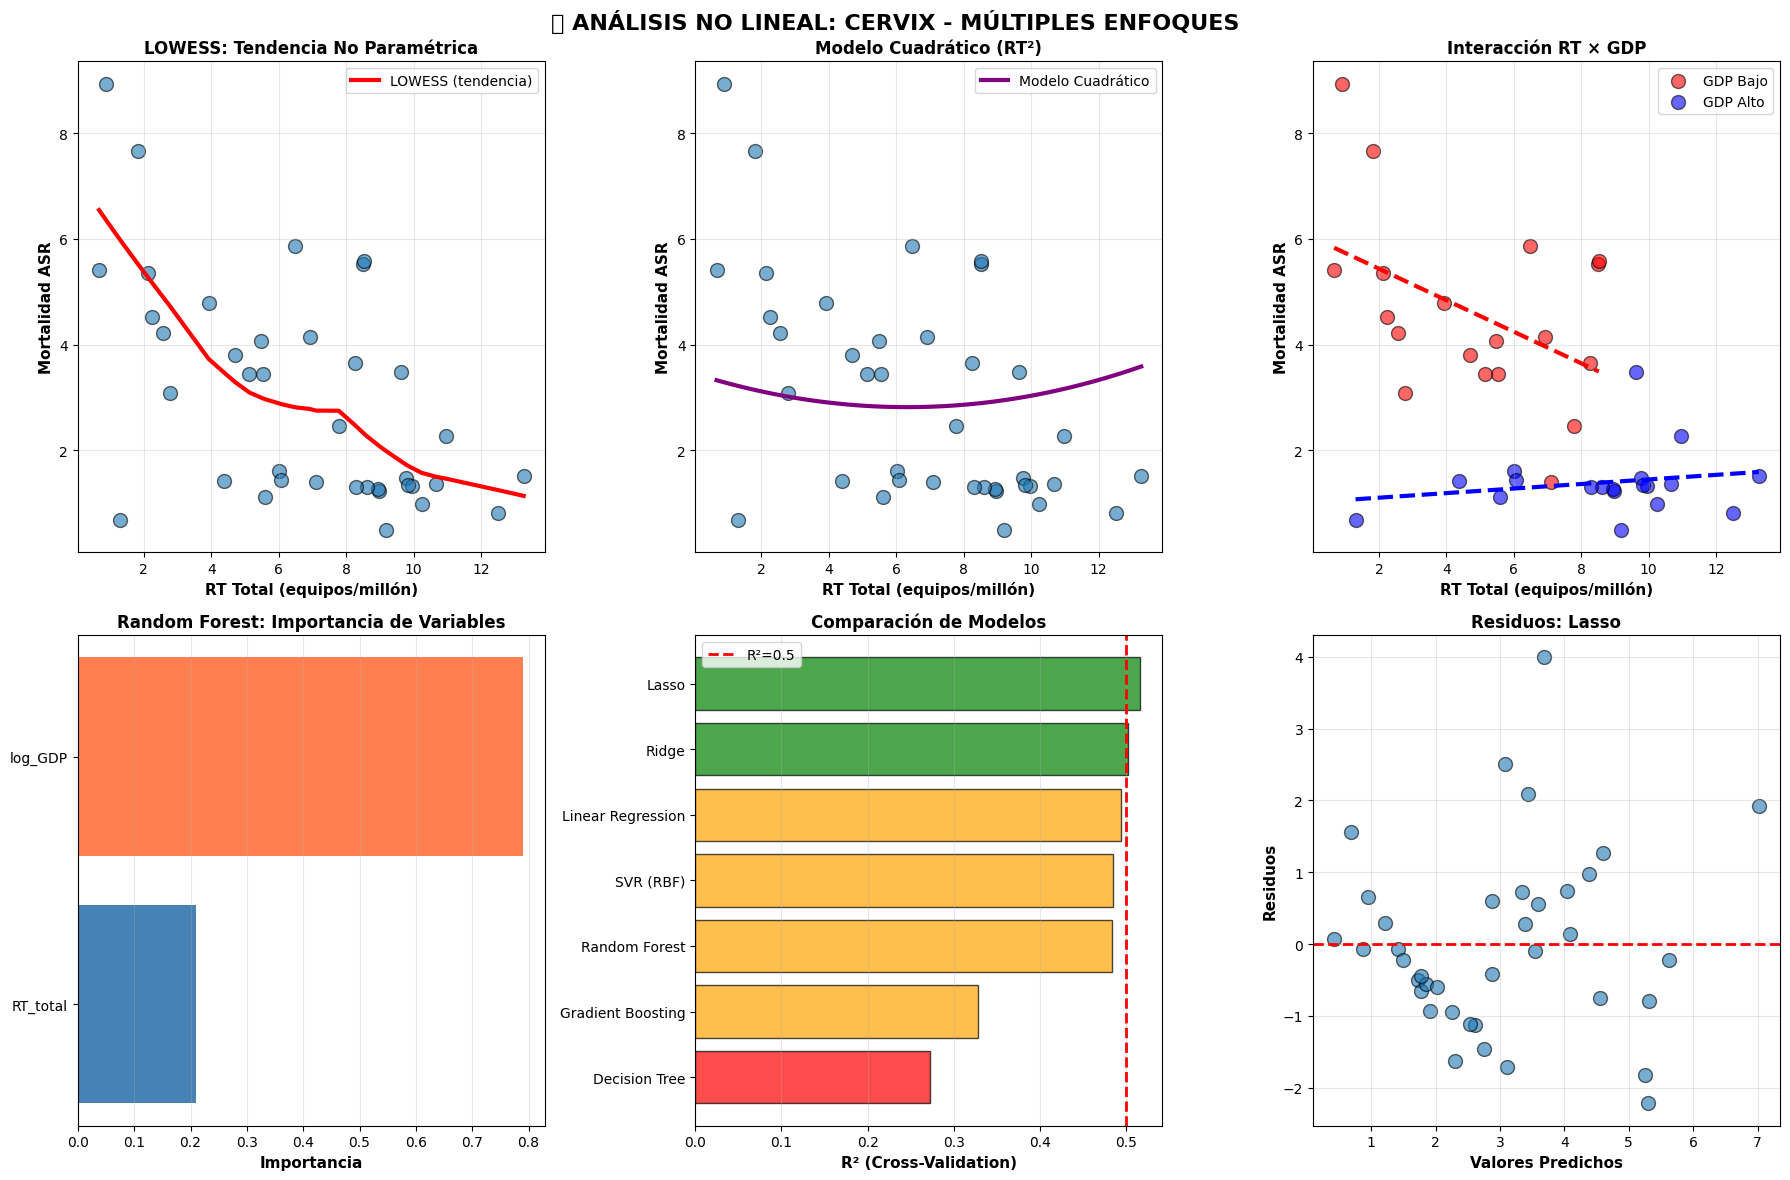


🎯 ANÁLISIS DE UMBRALES (THRESHOLD EFFECTS)

Umbral RT > 2:
  Coeficiente: -1.180
  p-value: 0.1121
  R² ajustado: 0.628
  ❌ No hay efecto significativo del umbral

Umbral RT > 3:
  Coeficiente: -0.304
  p-value: 0.6402
  R² ajustado: 0.603
  ❌ No hay efecto significativo del umbral

Umbral RT > 4:
  Coeficiente: -0.443
  p-value: 0.4840
  R² ajustado: 0.606
  ❌ No hay efecto significativo del umbral

Umbral RT > 5:
  Coeficiente: 0.004
  p-value: 0.9942
  R² ajustado: 0.600
  ❌ No hay efecto significativo del umbral

Umbral RT > 6:
  Coeficiente: 0.369
  p-value: 0.5146
  R² ajustado: 0.605
  ❌ No hay efecto significativo del umbral

🏆 MEJOR UMBRAL:

   RT > 2.0 equipos/millón
   R² ajustado: 0.628
   Efecto: -1.180 (p=0.1121)

🔮 PREDICCIONES CON MEJOR MODELO

PREDICCIONES PARA PAÍS CON GDP=$10,000:
--------------------------------------------------------------------------------
RT = 1.0 equipos/millón → Mortalidad predicha = 4.60
RT = 3.0 equipos/millón → Mortalidad predicha = 4.60
R

In [11]:
# ════════════════════════════════════════════════════════════════════════════
# ANÁLISIS NO LINEAL: CERVIX CON MÚLTIPLES MÉTODOS
# ════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import statsmodels.formula.api as smf
from statsmodels.nonparametric.smoothers_lowess import lowess

# ════════════════════════════════════════════════════════════════════════════
# 1. PREPARAR DATOS
# ════════════════════════════════════════════════════════════════════════════

df_cervix = df_clean[df_clean['Cancer_type'] == 'Cervix'].copy()
df_cervix['RT_total'] = df_cervix['Linac_per_million'] + df_cervix['Brachy_per_million']
df_cervix['log_GDP'] = np.log(df_cervix['GDP_per_capita'])

# Eliminar NaN
df_cervix = df_cervix.dropna(subset=['RT_total', 'Mortality_ASR', 'GDP_per_capita'])

print("="*80)
print("🎯 ANÁLISIS NO LINEAL: CERVIX")
print("="*80)
print(f"\nMuestra: n={len(df_cervix)} países")
print(f"Mortalidad - Rango: [{df_cervix['Mortality_ASR'].min():.2f}, {df_cervix['Mortality_ASR'].max():.2f}]")
print(f"RT_total - Rango: [{df_cervix['RT_total'].min():.2f}, {df_cervix['RT_total'].max():.2f}]")

# ════════════════════════════════════════════════════════════════════════════
# 2. MODELOS POLINOMIALES (REGRESIÓN CLÁSICA)
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("📐 MODELOS POLINOMIALES")
print("="*80 + "\n")

# Preparar datos
X = df_cervix[['RT_total', 'log_GDP']].values
y = df_cervix['Mortality_ASR'].values

resultados_poly = []

for grado in [1, 2, 3]:
    # Crear términos polinomiales
    from sklearn.preprocessing import PolynomialFeatures
    poly = PolynomialFeatures(degree=grado, include_bias=False)
    X_poly = poly.fit_transform(X)

    # Ajustar modelo
    model = LinearRegression()
    model.fit(X_poly, y)

    # Métricas
    y_pred = model.predict(X_poly)
    r2 = r2_score(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    mae = mean_absolute_error(y, y_pred)

    # Cross-validation
    cv_scores = cross_val_score(model, X_poly, y, cv=5, scoring='r2')

    resultados_poly.append({
        'Grado': grado,
        'R²': r2,
        'R²_CV': cv_scores.mean(),
        'RMSE': rmse,
        'MAE': mae
    })

    print(f"Polinomio grado {grado}:")
    print(f"  R² = {r2:.3f}")
    print(f"  R² (CV) = {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
    print(f"  RMSE = {rmse:.2f}")
    print(f"  MAE = {mae:.2f}\n")

# ════════════════════════════════════════════════════════════════════════════
# 3. MODELOS DE MACHINE LEARNING
# ════════════════════════════════════════════════════════════════════════════

print("="*80)
print("🤖 MODELOS DE MACHINE LEARNING")
print("="*80 + "\n")

# Estandarizar datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Definir modelos
modelos = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42),
    'SVR (RBF)': SVR(kernel='rbf', C=1.0, gamma='scale'),
    'Decision Tree': DecisionTreeRegressor(max_depth=4, random_state=42)
}

resultados_ml = []

for nombre, modelo in modelos.items():
    # Ajustar modelo
    modelo.fit(X_scaled, y)

    # Predicciones
    y_pred = modelo.predict(X_scaled)

    # Métricas
    r2 = r2_score(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    mae = mean_absolute_error(y, y_pred)

    # Cross-validation
    cv_scores = cross_val_score(modelo, X_scaled, y, cv=5, scoring='r2')

    resultados_ml.append({
        'Modelo': nombre,
        'R²': r2,
        'R²_CV': cv_scores.mean(),
        'CV_std': cv_scores.std(),
        'RMSE': rmse,
        'MAE': mae
    })

    print(f"{nombre}:")
    print(f"  R² = {r2:.3f}")
    print(f"  R² (CV) = {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
    print(f"  RMSE = {rmse:.2f}")
    print(f"  MAE = {mae:.2f}\n")

# ════════════════════════════════════════════════════════════════════════════
# 4. MODELO CON TÉRMINOS DE INTERACCIÓN
# ════════════════════════════════════════════════════════════════════════════

print("="*80)
print("🔄 MODELO CON INTERACCIÓN RT × GDP")
print("="*80 + "\n")

# Crear término de interacción
df_cervix['RT_x_logGDP'] = df_cervix['RT_total'] * df_cervix['log_GDP']

# Modelo con interacción
model_int = smf.ols('Mortality_ASR ~ RT_total + log_GDP + RT_x_logGDP',
                    data=df_cervix).fit()

print(model_int.summary())

print(f"\n🎯 INTERPRETACIÓN INTERACCIÓN:")
print(f"   Coef RT_total: {model_int.params['RT_total']:.3f}")
print(f"   Coef RT×GDP: {model_int.params['RT_x_logGDP']:.3f}")
print(f"   p-value interacción: {model_int.pvalues['RT_x_logGDP']:.4f}")

if model_int.pvalues['RT_x_logGDP'] < 0.05:
    print("\n   ✅ INTERACCIÓN SIGNIFICATIVA:")
    print("   → Efecto de RT DEPENDE del nivel de GDP")
else:
    print("\n   ❌ Interacción NO significativa")

# ════════════════════════════════════════════════════════════════════════════
# 5. MODELO CON TÉRMINOS CUADRÁTICOS
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("📈 MODELO CON TÉRMINOS CUADRÁTICOS (CURVAS)")
print("="*80 + "\n")

df_cervix['RT_squared'] = df_cervix['RT_total'] ** 2

model_quad = smf.ols('Mortality_ASR ~ RT_total + RT_squared + log_GDP',
                     data=df_cervix).fit()

print(model_quad.summary())

print(f"\n🎯 INTERPRETACIÓN CUADRÁTICA:")
print(f"   Coef RT_total: {model_quad.params['RT_total']:.3f}")
print(f"   Coef RT²: {model_quad.params['RT_squared']:.4f}")
print(f"   p-value RT²: {model_quad.pvalues['RT_squared']:.4f}")

if model_quad.pvalues['RT_squared'] < 0.05:
    if model_quad.params['RT_squared'] > 0:
        print("\n   ⚠️ CURVA EN U: Efecto aumenta con RT (rendimientos crecientes)")
    else:
        print("\n   ✅ CURVA INVERTIDA: Rendimientos decrecientes")
        print("   → Beneficio de RT disminuye con más equipos")
else:
    print("\n   ❌ Relación NO es cuadrática (lineal es suficiente)")

# ════════════════════════════════════════════════════════════════════════════
# 6. REGRESIÓN LOWESS (SUAVIZADO NO PARAMÉTRICO)
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("📉 REGRESIÓN LOWESS (TENDENCIA SUAVIZADA)")
print("="*80 + "\n")

# Ordenar por RT_total
df_sorted = df_cervix.sort_values('RT_total')

# LOWESS para RT vs Mortalidad (sin controlar GDP)
lowess_result = lowess(df_sorted['Mortality_ASR'], df_sorted['RT_total'], frac=0.5)

print("LOWESS calculado (tendencia no paramétrica)")
print("Ver gráfica para interpretación visual")

# ════════════════════════════════════════════════════════════════════════════
# 7. COMPARACIÓN FINAL DE TODOS LOS MODELOS
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("🏆 RANKING DE MODELOS (POR R² CROSS-VALIDATION)")
print("="*80 + "\n")

df_resultados = pd.DataFrame(resultados_ml)
df_resultados = df_resultados.sort_values('R²_CV', ascending=False)

print(df_resultados.to_string(index=False))

print("\n" + "="*80)
print("✅ MEJOR MODELO:")
print("="*80)
mejor = df_resultados.iloc[0]
print(f"\n   Modelo: {mejor['Modelo']}")
print(f"   R² (CV): {mejor['R²_CV']:.3f} ± {mejor['CV_std']:.3f}")
print(f"   RMSE: {mejor['RMSE']:.2f}")
print(f"   MAE: {mejor['MAE']:.2f}")

# ════════════════════════════════════════════════════════════════════════════
# 8. VISUALIZACIONES
# ════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('🎯 ANÁLISIS NO LINEAL: CERVIX - MÚLTIPLES ENFOQUES',
             fontsize=16, fontweight='bold')

# 1. Scatter con LOWESS
ax = axes[0, 0]
ax.scatter(df_cervix['RT_total'], df_cervix['Mortality_ASR'],
           alpha=0.6, s=100, edgecolors='black')
ax.plot(lowess_result[:, 0], lowess_result[:, 1],
        color='red', linewidth=3, label='LOWESS (tendencia)')
ax.set_xlabel('RT Total (equipos/millón)', fontsize=11, fontweight='bold')
ax.set_ylabel('Mortalidad ASR', fontsize=11, fontweight='bold')
ax.set_title('LOWESS: Tendencia No Paramétrica', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# 2. Modelo Cuadrático
ax = axes[0, 1]
RT_range = np.linspace(df_cervix['RT_total'].min(), df_cervix['RT_total'].max(), 100)
GDP_mean = df_cervix['log_GDP'].mean()
pred_quad = (model_quad.params['Intercept'] +
             model_quad.params['RT_total'] * RT_range +
             model_quad.params['RT_squared'] * RT_range**2 +
             model_quad.params['log_GDP'] * GDP_mean)
ax.scatter(df_cervix['RT_total'], df_cervix['Mortality_ASR'],
           alpha=0.6, s=100, edgecolors='black')
ax.plot(RT_range, pred_quad, color='purple', linewidth=3, label='Modelo Cuadrático')
ax.set_xlabel('RT Total (equipos/millón)', fontsize=11, fontweight='bold')
ax.set_ylabel('Mortalidad ASR', fontsize=11, fontweight='bold')
ax.set_title('Modelo Cuadrático (RT²)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# 3. Interacción RT × GDP
ax = axes[0, 2]
# Dividir por GDP
df_low_gdp = df_cervix[df_cervix['GDP_per_capita'] < df_cervix['GDP_per_capita'].median()]
df_high_gdp = df_cervix[df_cervix['GDP_per_capita'] >= df_cervix['GDP_per_capita'].median()]

ax.scatter(df_low_gdp['RT_total'], df_low_gdp['Mortality_ASR'],
           alpha=0.6, s=100, color='red', edgecolors='black', label='GDP Bajo')
ax.scatter(df_high_gdp['RT_total'], df_high_gdp['Mortality_ASR'],
           alpha=0.6, s=100, color='blue', edgecolors='black', label='GDP Alto')

# Líneas de tendencia
z_low = np.polyfit(df_low_gdp['RT_total'], df_low_gdp['Mortality_ASR'], 1)
z_high = np.polyfit(df_high_gdp['RT_total'], df_high_gdp['Mortality_ASR'], 1)
p_low = np.poly1d(z_low)
p_high = np.poly1d(z_high)

RT_low = np.linspace(df_low_gdp['RT_total'].min(), df_low_gdp['RT_total'].max(), 100)
RT_high = np.linspace(df_high_gdp['RT_total'].min(), df_high_gdp['RT_total'].max(), 100)

ax.plot(RT_low, p_low(RT_low), color='red', linewidth=3, linestyle='--')
ax.plot(RT_high, p_high(RT_high), color='blue', linewidth=3, linestyle='--')

ax.set_xlabel('RT Total (equipos/millón)', fontsize=11, fontweight='bold')
ax.set_ylabel('Mortalidad ASR', fontsize=11, fontweight='bold')
ax.set_title('Interacción RT × GDP', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# 4. Random Forest - Feature Importance
ax = axes[1, 0]
rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_scaled, y)
importances = rf_model.feature_importances_
features = ['RT_total', 'log_GDP']
ax.barh(features, importances, color=['steelblue', 'coral'])
ax.set_xlabel('Importancia', fontsize=11, fontweight='bold')
ax.set_title('Random Forest: Importancia de Variables', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3, axis='x')

# 5. Comparación de Modelos (R² CV)
ax = axes[1, 1]
df_plot = df_resultados.sort_values('R²_CV')
colors = ['green' if x > 0.5 else 'orange' if x > 0.3 else 'red' for x in df_plot['R²_CV']]
ax.barh(df_plot['Modelo'], df_plot['R²_CV'], color=colors, alpha=0.7, edgecolor='black')
ax.axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='R²=0.5')
ax.set_xlabel('R² (Cross-Validation)', fontsize=11, fontweight='bold')
ax.set_title('Comparación de Modelos', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3, axis='x')

# 6. Residuos del Mejor Modelo
ax = axes[1, 2]
mejor_modelo_nombre = df_resultados.iloc[0]['Modelo']
mejor_modelo_obj = modelos[mejor_modelo_nombre]
mejor_modelo_obj.fit(X_scaled, y)
y_pred_mejor = mejor_modelo_obj.predict(X_scaled)
residuos = y - y_pred_mejor

ax.scatter(y_pred_mejor, residuos, alpha=0.6, s=100, edgecolors='black')
ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Valores Predichos', fontsize=11, fontweight='bold')
ax.set_ylabel('Residuos', fontsize=11, fontweight='bold')
ax.set_title(f'Residuos: {mejor_modelo_nombre}', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════════════════════
# 9. ANÁLISIS DE UMBRALES (SEGMENTED REGRESSION)
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("🎯 ANÁLISIS DE UMBRALES (THRESHOLD EFFECTS)")
print("="*80 + "\n")

# Probar diferentes umbrales de RT
umbrales = [2, 3, 4, 5, 6]
resultados_umbrales = []

for umbral in umbrales:
    df_cervix['RT_above_threshold'] = (df_cervix['RT_total'] > umbral).astype(int)

    model_threshold = smf.ols('Mortality_ASR ~ RT_above_threshold + log_GDP',
                              data=df_cervix).fit()

    resultados_umbrales.append({
        'Umbral': umbral,
        'Coef': model_threshold.params['RT_above_threshold'],
        'p-value': model_threshold.pvalues['RT_above_threshold'],
        'R²': model_threshold.rsquared_adj
    })

    print(f"Umbral RT > {umbral}:")
    print(f"  Coeficiente: {model_threshold.params['RT_above_threshold']:.3f}")
    print(f"  p-value: {model_threshold.pvalues['RT_above_threshold']:.4f}")
    print(f"  R² ajustado: {model_threshold.rsquared_adj:.3f}")

    if model_threshold.pvalues['RT_above_threshold'] < 0.05:
        if model_threshold.params['RT_above_threshold'] < 0:
            print(f"  ✅ Tener >={umbral} equipos/millón REDUCE mortalidad")
        else:
            print(f"  ⚠️ Tener >={umbral} equipos/millón AUMENTA mortalidad")
    else:
        print(f"  ❌ No hay efecto significativo del umbral")
    print()

# Encontrar mejor umbral
df_umbrales = pd.DataFrame(resultados_umbrales)
mejor_umbral = df_umbrales.loc[df_umbrales['R²'].idxmax()]

print("="*80)
print("🏆 MEJOR UMBRAL:")
print("="*80)
print(f"\n   RT > {mejor_umbral['Umbral']} equipos/millón")
print(f"   R² ajustado: {mejor_umbral['R²']:.3f}")
print(f"   Efecto: {mejor_umbral['Coef']:.3f} (p={mejor_umbral['p-value']:.4f})")

# ════════════════════════════════════════════════════════════════════════════
# 10. PREDICCIONES CON MEJOR MODELO
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("🔮 PREDICCIONES CON MEJOR MODELO")
print("="*80 + "\n")

# Usar el mejor modelo ML
mejor_modelo_obj.fit(X_scaled, y)

# Crear escenarios
escenarios = pd.DataFrame({
    'RT_total': [1, 3, 5, 7, 10],
    'log_GDP': [np.log(10000), np.log(10000), np.log(10000), np.log(10000), np.log(10000)]
})

escenarios_scaled = scaler.transform(escenarios)
predicciones = mejor_modelo_obj.predict(escenarios_scaled)

print("PREDICCIONES PARA PAÍS CON GDP=$10,000:")
print("-"*80)
for i, row in escenarios.iterrows():
    print(f"RT = {row['RT_total']:.1f} equipos/millón → Mortalidad predicha = {predicciones[i]:.2f}")

# Escenarios con diferentes GDP
print("\n" + "="*80)
print("EFECTO DE GDP EN PREDICCIONES:")
print("="*80 + "\n")

escenarios_gdp = pd.DataFrame({
    'RT_total': [5, 5, 5],
    'log_GDP': [np.log(5000), np.log(20000), np.log(50000)]
})

escenarios_gdp_scaled = scaler.transform(escenarios_gdp)
predicciones_gdp = mejor_modelo_obj.predict(escenarios_gdp_scaled)

gdp_values = [5000, 20000, 50000]
print("CON RT=5 equipos/millón:")
print("-"*80)
for i, gdp in enumerate(gdp_values):
    print(f"GDP = ${gdp:,} → Mortalidad predicha = {predicciones_gdp[i]:.2f}")

# ════════════════════════════════════════════════════════════════════════════
# 11. RESUMEN EJECUTIVO
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("📋 RESUMEN EJECUTIVO")
print("="*80 + "\n")

print("1️⃣ MEJOR MODELO PREDICTIVO:")
print(f"   → {mejor['Modelo']}")
print(f"   → R² (CV): {mejor['R²_CV']:.3f}")
print(f"   → Error medio: {mejor['MAE']:.2f} puntos de mortalidad\n")

print("2️⃣ LINEALIDAD:")
if model_quad.pvalues['RT_squared'] < 0.05:
    print("   → ⚠️ Relación NO es lineal (término cuadrático significativo)")
else:
    print("   → ✅ Relación aproximadamente lineal\n")

print("3️⃣ INTERACCIÓN RT × GDP:")
if model_int.pvalues['RT_x_logGDP'] < 0.05:
    print("   → ✅ Efecto de RT DEPENDE del nivel de GDP")
    print("   → Países ricos/pobres responden diferente a RT")
else:
    print("   → ❌ Efecto de RT es similar independiente del GDP\n")

print("4️⃣ UMBRAL ÓPTIMO:")
print(f"   → RT > {mejor_umbral['Umbral']} equipos/millón")
print(f"   → Diferencia en mortalidad: {mejor_umbral['Coef']:.2f} puntos\n")

print("5️⃣ IMPORTANCIA DE VARIABLES (Random Forest):")
rf_importances = dict(zip(features, rf_model.feature_importances_))
for feat, imp in sorted(rf_importances.items(), key=lambda x: x[1], reverse=True):
    print(f"   → {feat}: {imp:.3f} ({imp*100:.1f}%)")

print("\n" + "="*80)
print("✅ ANÁLISIS COMPLETADO")
print("="*80)

🎯 ANÁLISIS NO LINEAL: CERVIX

Muestra: n=38 países
Mortalidad - Rango: [3.71, 20.19]
RT_total - Rango: [0.67, 13.26]

📐 MODELOS POLINOMIALES

Polinomio grado 1:
  R² = 0.321
  R² (CV) = -0.063 ± 0.272
  RMSE = 2.73
  MAE = 2.28

Polinomio grado 2:
  R² = 0.390
  R² (CV) = -0.175 ± 0.570
  RMSE = 2.59
  MAE = 2.03

Polinomio grado 3:
  R² = 0.459
  R² (CV) = -0.292 ± 0.660
  RMSE = 2.44
  MAE = 1.90

🤖 MODELOS DE MACHINE LEARNING

Linear Regression:
  R² = 0.321
  R² (CV) = -0.063 ± 0.272
  RMSE = 2.73
  MAE = 2.28

Ridge:
  R² = 0.319
  R² (CV) = -0.001 ± 0.201
  RMSE = 2.74
  MAE = 2.28

Lasso:
  R² = 0.314
  R² (CV) = -0.009 ± 0.176
  RMSE = 2.75
  MAE = 2.28

Random Forest:
  R² = 0.914
  R² (CV) = -0.120 ± 1.063
  RMSE = 0.98
  MAE = 0.76

Gradient Boosting:
  R² = 0.998
  R² (CV) = -0.499 ± 1.592
  RMSE = 0.14
  MAE = 0.12

SVR (RBF):
  R² = 0.240
  R² (CV) = 0.027 ± 0.098
  RMSE = 2.89
  MAE = 2.17

Decision Tree:
  R² = 0.904
  R² (CV) = -0.991 ± 2.206
  RMSE = 1.03
  MAE = 0.64

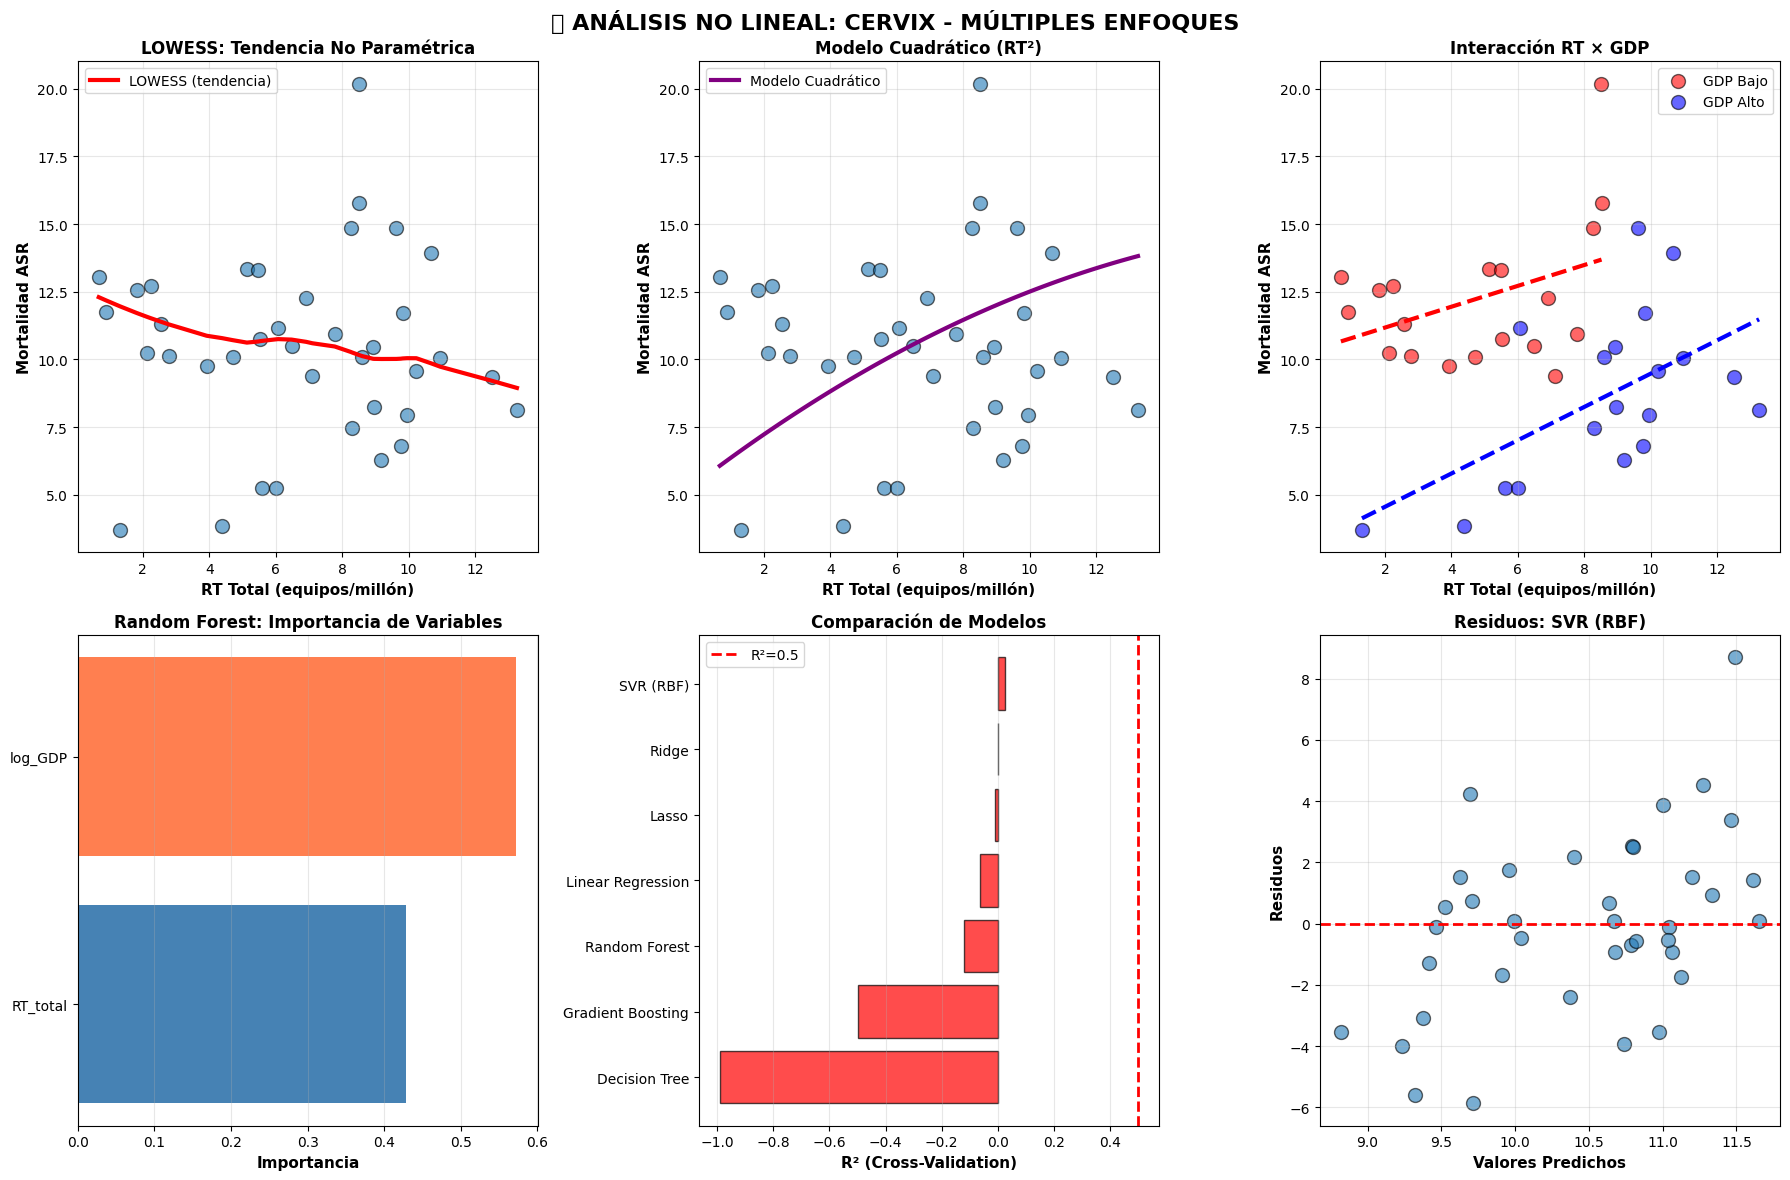


🎯 ANÁLISIS DE UMBRALES (THRESHOLD EFFECTS)

Umbral RT > 2:
  Coeficiente: 1.985
  p-value: 0.2784
  R² ajustado: 0.117
  ❌ No hay efecto significativo del umbral

Umbral RT > 3:
  Coeficiente: 2.222
  p-value: 0.1559
  R² ajustado: 0.138
  ❌ No hay efecto significativo del umbral

Umbral RT > 4:
  Coeficiente: 2.474
  p-value: 0.1039
  R² ajustado: 0.154
  ❌ No hay efecto significativo del umbral

Umbral RT > 5:
  Coeficiente: 3.787
  p-value: 0.0062
  R² ajustado: 0.265
  ⚠️ Tener >=5 equipos/millón AUMENTA mortalidad

Umbral RT > 6:
  Coeficiente: 3.565
  p-value: 0.0069
  R² ajustado: 0.261
  ⚠️ Tener >=6 equipos/millón AUMENTA mortalidad

🏆 MEJOR UMBRAL:

   RT > 5.0 equipos/millón
   R² ajustado: 0.265
   Efecto: 3.787 (p=0.0062)

🔮 PREDICCIONES CON MEJOR MODELO

PREDICCIONES PARA PAÍS CON GDP=$10,000:
--------------------------------------------------------------------------------
RT = 1.0 equipos/millón → Mortalidad predicha = 11.06
RT = 3.0 equipos/millón → Mortalidad predicha

In [12]:
# ════════════════════════════════════════════════════════════════════════════
# ANÁLISIS NO LINEAL: PROSTATE CON MÚLTIPLES MÉTODOS
# ════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import statsmodels.formula.api as smf
from statsmodels.nonparametric.smoothers_lowess import lowess

# ════════════════════════════════════════════════════════════════════════════
# 1. PREPARAR DATOS
# ════════════════════════════════════════════════════════════════════════════

df_cervix = df_clean[df_clean['Cancer_type'] == 'Prostate'].copy()
df_cervix['RT_total'] = df_cervix['Linac_per_million'] + df_cervix['Brachy_per_million']
df_cervix['log_GDP'] = np.log(df_cervix['GDP_per_capita'])

# Eliminar NaN
df_cervix = df_cervix.dropna(subset=['RT_total', 'Mortality_ASR', 'GDP_per_capita'])

print("="*80)
print("🎯 ANÁLISIS NO LINEAL: CERVIX")
print("="*80)
print(f"\nMuestra: n={len(df_cervix)} países")
print(f"Mortalidad - Rango: [{df_cervix['Mortality_ASR'].min():.2f}, {df_cervix['Mortality_ASR'].max():.2f}]")
print(f"RT_total - Rango: [{df_cervix['RT_total'].min():.2f}, {df_cervix['RT_total'].max():.2f}]")

# ════════════════════════════════════════════════════════════════════════════
# 2. MODELOS POLINOMIALES (REGRESIÓN CLÁSICA)
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("📐 MODELOS POLINOMIALES")
print("="*80 + "\n")

# Preparar datos
X = df_cervix[['RT_total', 'log_GDP']].values
y = df_cervix['Mortality_ASR'].values

resultados_poly = []

for grado in [1, 2, 3]:
    # Crear términos polinomiales
    from sklearn.preprocessing import PolynomialFeatures
    poly = PolynomialFeatures(degree=grado, include_bias=False)
    X_poly = poly.fit_transform(X)

    # Ajustar modelo
    model = LinearRegression()
    model.fit(X_poly, y)

    # Métricas
    y_pred = model.predict(X_poly)
    r2 = r2_score(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    mae = mean_absolute_error(y, y_pred)

    # Cross-validation
    cv_scores = cross_val_score(model, X_poly, y, cv=5, scoring='r2')

    resultados_poly.append({
        'Grado': grado,
        'R²': r2,
        'R²_CV': cv_scores.mean(),
        'RMSE': rmse,
        'MAE': mae
    })

    print(f"Polinomio grado {grado}:")
    print(f"  R² = {r2:.3f}")
    print(f"  R² (CV) = {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
    print(f"  RMSE = {rmse:.2f}")
    print(f"  MAE = {mae:.2f}\n")

# ════════════════════════════════════════════════════════════════════════════
# 3. MODELOS DE MACHINE LEARNING
# ════════════════════════════════════════════════════════════════════════════

print("="*80)
print("🤖 MODELOS DE MACHINE LEARNING")
print("="*80 + "\n")

# Estandarizar datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Definir modelos
modelos = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42),
    'SVR (RBF)': SVR(kernel='rbf', C=1.0, gamma='scale'),
    'Decision Tree': DecisionTreeRegressor(max_depth=4, random_state=42)
}

resultados_ml = []

for nombre, modelo in modelos.items():
    # Ajustar modelo
    modelo.fit(X_scaled, y)

    # Predicciones
    y_pred = modelo.predict(X_scaled)

    # Métricas
    r2 = r2_score(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    mae = mean_absolute_error(y, y_pred)

    # Cross-validation
    cv_scores = cross_val_score(modelo, X_scaled, y, cv=5, scoring='r2')

    resultados_ml.append({
        'Modelo': nombre,
        'R²': r2,
        'R²_CV': cv_scores.mean(),
        'CV_std': cv_scores.std(),
        'RMSE': rmse,
        'MAE': mae
    })

    print(f"{nombre}:")
    print(f"  R² = {r2:.3f}")
    print(f"  R² (CV) = {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
    print(f"  RMSE = {rmse:.2f}")
    print(f"  MAE = {mae:.2f}\n")

# ════════════════════════════════════════════════════════════════════════════
# 4. MODELO CON TÉRMINOS DE INTERACCIÓN
# ════════════════════════════════════════════════════════════════════════════

print("="*80)
print("🔄 MODELO CON INTERACCIÓN RT × GDP")
print("="*80 + "\n")

# Crear término de interacción
df_cervix['RT_x_logGDP'] = df_cervix['RT_total'] * df_cervix['log_GDP']

# Modelo con interacción
model_int = smf.ols('Mortality_ASR ~ RT_total + log_GDP + RT_x_logGDP',
                    data=df_cervix).fit()

print(model_int.summary())

print(f"\n🎯 INTERPRETACIÓN INTERACCIÓN:")
print(f"   Coef RT_total: {model_int.params['RT_total']:.3f}")
print(f"   Coef RT×GDP: {model_int.params['RT_x_logGDP']:.3f}")
print(f"   p-value interacción: {model_int.pvalues['RT_x_logGDP']:.4f}")

if model_int.pvalues['RT_x_logGDP'] < 0.05:
    print("\n   ✅ INTERACCIÓN SIGNIFICATIVA:")
    print("   → Efecto de RT DEPENDE del nivel de GDP")
else:
    print("\n   ❌ Interacción NO significativa")

# ════════════════════════════════════════════════════════════════════════════
# 5. MODELO CON TÉRMINOS CUADRÁTICOS
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("📈 MODELO CON TÉRMINOS CUADRÁTICOS (CURVAS)")
print("="*80 + "\n")

df_cervix['RT_squared'] = df_cervix['RT_total'] ** 2

model_quad = smf.ols('Mortality_ASR ~ RT_total + RT_squared + log_GDP',
                     data=df_cervix).fit()

print(model_quad.summary())

print(f"\n🎯 INTERPRETACIÓN CUADRÁTICA:")
print(f"   Coef RT_total: {model_quad.params['RT_total']:.3f}")
print(f"   Coef RT²: {model_quad.params['RT_squared']:.4f}")
print(f"   p-value RT²: {model_quad.pvalues['RT_squared']:.4f}")

if model_quad.pvalues['RT_squared'] < 0.05:
    if model_quad.params['RT_squared'] > 0:
        print("\n   ⚠️ CURVA EN U: Efecto aumenta con RT (rendimientos crecientes)")
    else:
        print("\n   ✅ CURVA INVERTIDA: Rendimientos decrecientes")
        print("   → Beneficio de RT disminuye con más equipos")
else:
    print("\n   ❌ Relación NO es cuadrática (lineal es suficiente)")

# ════════════════════════════════════════════════════════════════════════════
# 6. REGRESIÓN LOWESS (SUAVIZADO NO PARAMÉTRICO)
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("📉 REGRESIÓN LOWESS (TENDENCIA SUAVIZADA)")
print("="*80 + "\n")

# Ordenar por RT_total
df_sorted = df_cervix.sort_values('RT_total')

# LOWESS para RT vs Mortalidad (sin controlar GDP)
lowess_result = lowess(df_sorted['Mortality_ASR'], df_sorted['RT_total'], frac=0.5)

print("LOWESS calculado (tendencia no paramétrica)")
print("Ver gráfica para interpretación visual")

# ════════════════════════════════════════════════════════════════════════════
# 7. COMPARACIÓN FINAL DE TODOS LOS MODELOS
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("🏆 RANKING DE MODELOS (POR R² CROSS-VALIDATION)")
print("="*80 + "\n")

df_resultados = pd.DataFrame(resultados_ml)
df_resultados = df_resultados.sort_values('R²_CV', ascending=False)

print(df_resultados.to_string(index=False))

print("\n" + "="*80)
print("✅ MEJOR MODELO:")
print("="*80)
mejor = df_resultados.iloc[0]
print(f"\n   Modelo: {mejor['Modelo']}")
print(f"   R² (CV): {mejor['R²_CV']:.3f} ± {mejor['CV_std']:.3f}")
print(f"   RMSE: {mejor['RMSE']:.2f}")
print(f"   MAE: {mejor['MAE']:.2f}")

# ════════════════════════════════════════════════════════════════════════════
# 8. VISUALIZACIONES
# ════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('🎯 ANÁLISIS NO LINEAL: CERVIX - MÚLTIPLES ENFOQUES',
             fontsize=16, fontweight='bold')

# 1. Scatter con LOWESS
ax = axes[0, 0]
ax.scatter(df_cervix['RT_total'], df_cervix['Mortality_ASR'],
           alpha=0.6, s=100, edgecolors='black')
ax.plot(lowess_result[:, 0], lowess_result[:, 1],
        color='red', linewidth=3, label='LOWESS (tendencia)')
ax.set_xlabel('RT Total (equipos/millón)', fontsize=11, fontweight='bold')
ax.set_ylabel('Mortalidad ASR', fontsize=11, fontweight='bold')
ax.set_title('LOWESS: Tendencia No Paramétrica', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# 2. Modelo Cuadrático
ax = axes[0, 1]
RT_range = np.linspace(df_cervix['RT_total'].min(), df_cervix['RT_total'].max(), 100)
GDP_mean = df_cervix['log_GDP'].mean()
pred_quad = (model_quad.params['Intercept'] +
             model_quad.params['RT_total'] * RT_range +
             model_quad.params['RT_squared'] * RT_range**2 +
             model_quad.params['log_GDP'] * GDP_mean)
ax.scatter(df_cervix['RT_total'], df_cervix['Mortality_ASR'],
           alpha=0.6, s=100, edgecolors='black')
ax.plot(RT_range, pred_quad, color='purple', linewidth=3, label='Modelo Cuadrático')
ax.set_xlabel('RT Total (equipos/millón)', fontsize=11, fontweight='bold')
ax.set_ylabel('Mortalidad ASR', fontsize=11, fontweight='bold')
ax.set_title('Modelo Cuadrático (RT²)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# 3. Interacción RT × GDP
ax = axes[0, 2]
# Dividir por GDP
df_low_gdp = df_cervix[df_cervix['GDP_per_capita'] < df_cervix['GDP_per_capita'].median()]
df_high_gdp = df_cervix[df_cervix['GDP_per_capita'] >= df_cervix['GDP_per_capita'].median()]

ax.scatter(df_low_gdp['RT_total'], df_low_gdp['Mortality_ASR'],
           alpha=0.6, s=100, color='red', edgecolors='black', label='GDP Bajo')
ax.scatter(df_high_gdp['RT_total'], df_high_gdp['Mortality_ASR'],
           alpha=0.6, s=100, color='blue', edgecolors='black', label='GDP Alto')

# Líneas de tendencia
z_low = np.polyfit(df_low_gdp['RT_total'], df_low_gdp['Mortality_ASR'], 1)
z_high = np.polyfit(df_high_gdp['RT_total'], df_high_gdp['Mortality_ASR'], 1)
p_low = np.poly1d(z_low)
p_high = np.poly1d(z_high)

RT_low = np.linspace(df_low_gdp['RT_total'].min(), df_low_gdp['RT_total'].max(), 100)
RT_high = np.linspace(df_high_gdp['RT_total'].min(), df_high_gdp['RT_total'].max(), 100)

ax.plot(RT_low, p_low(RT_low), color='red', linewidth=3, linestyle='--')
ax.plot(RT_high, p_high(RT_high), color='blue', linewidth=3, linestyle='--')

ax.set_xlabel('RT Total (equipos/millón)', fontsize=11, fontweight='bold')
ax.set_ylabel('Mortalidad ASR', fontsize=11, fontweight='bold')
ax.set_title('Interacción RT × GDP', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# 4. Random Forest - Feature Importance
ax = axes[1, 0]
rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_scaled, y)
importances = rf_model.feature_importances_
features = ['RT_total', 'log_GDP']
ax.barh(features, importances, color=['steelblue', 'coral'])
ax.set_xlabel('Importancia', fontsize=11, fontweight='bold')
ax.set_title('Random Forest: Importancia de Variables', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3, axis='x')

# 5. Comparación de Modelos (R² CV)
ax = axes[1, 1]
df_plot = df_resultados.sort_values('R²_CV')
colors = ['green' if x > 0.5 else 'orange' if x > 0.3 else 'red' for x in df_plot['R²_CV']]
ax.barh(df_plot['Modelo'], df_plot['R²_CV'], color=colors, alpha=0.7, edgecolor='black')
ax.axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='R²=0.5')
ax.set_xlabel('R² (Cross-Validation)', fontsize=11, fontweight='bold')
ax.set_title('Comparación de Modelos', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3, axis='x')

# 6. Residuos del Mejor Modelo
ax = axes[1, 2]
mejor_modelo_nombre = df_resultados.iloc[0]['Modelo']
mejor_modelo_obj = modelos[mejor_modelo_nombre]
mejor_modelo_obj.fit(X_scaled, y)
y_pred_mejor = mejor_modelo_obj.predict(X_scaled)
residuos = y - y_pred_mejor

ax.scatter(y_pred_mejor, residuos, alpha=0.6, s=100, edgecolors='black')
ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Valores Predichos', fontsize=11, fontweight='bold')
ax.set_ylabel('Residuos', fontsize=11, fontweight='bold')
ax.set_title(f'Residuos: {mejor_modelo_nombre}', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════════════════════
# 9. ANÁLISIS DE UMBRALES (SEGMENTED REGRESSION)
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("🎯 ANÁLISIS DE UMBRALES (THRESHOLD EFFECTS)")
print("="*80 + "\n")

# Probar diferentes umbrales de RT
umbrales = [2, 3, 4, 5, 6]
resultados_umbrales = []

for umbral in umbrales:
    df_cervix['RT_above_threshold'] = (df_cervix['RT_total'] > umbral).astype(int)

    model_threshold = smf.ols('Mortality_ASR ~ RT_above_threshold + log_GDP',
                              data=df_cervix).fit()

    resultados_umbrales.append({
        'Umbral': umbral,
        'Coef': model_threshold.params['RT_above_threshold'],
        'p-value': model_threshold.pvalues['RT_above_threshold'],
        'R²': model_threshold.rsquared_adj
    })

    print(f"Umbral RT > {umbral}:")
    print(f"  Coeficiente: {model_threshold.params['RT_above_threshold']:.3f}")
    print(f"  p-value: {model_threshold.pvalues['RT_above_threshold']:.4f}")
    print(f"  R² ajustado: {model_threshold.rsquared_adj:.3f}")

    if model_threshold.pvalues['RT_above_threshold'] < 0.05:
        if model_threshold.params['RT_above_threshold'] < 0:
            print(f"  ✅ Tener >={umbral} equipos/millón REDUCE mortalidad")
        else:
            print(f"  ⚠️ Tener >={umbral} equipos/millón AUMENTA mortalidad")
    else:
        print(f"  ❌ No hay efecto significativo del umbral")
    print()

# Encontrar mejor umbral
df_umbrales = pd.DataFrame(resultados_umbrales)
mejor_umbral = df_umbrales.loc[df_umbrales['R²'].idxmax()]

print("="*80)
print("🏆 MEJOR UMBRAL:")
print("="*80)
print(f"\n   RT > {mejor_umbral['Umbral']} equipos/millón")
print(f"   R² ajustado: {mejor_umbral['R²']:.3f}")
print(f"   Efecto: {mejor_umbral['Coef']:.3f} (p={mejor_umbral['p-value']:.4f})")

# ════════════════════════════════════════════════════════════════════════════
# 10. PREDICCIONES CON MEJOR MODELO
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("🔮 PREDICCIONES CON MEJOR MODELO")
print("="*80 + "\n")

# Usar el mejor modelo ML
mejor_modelo_obj.fit(X_scaled, y)

# Crear escenarios
escenarios = pd.DataFrame({
    'RT_total': [1, 3, 5, 7, 10],
    'log_GDP': [np.log(10000), np.log(10000), np.log(10000), np.log(10000), np.log(10000)]
})

escenarios_scaled = scaler.transform(escenarios)
predicciones = mejor_modelo_obj.predict(escenarios_scaled)

print("PREDICCIONES PARA PAÍS CON GDP=$10,000:")
print("-"*80)
for i, row in escenarios.iterrows():
    print(f"RT = {row['RT_total']:.1f} equipos/millón → Mortalidad predicha = {predicciones[i]:.2f}")

# Escenarios con diferentes GDP
print("\n" + "="*80)
print("EFECTO DE GDP EN PREDICCIONES:")
print("="*80 + "\n")

escenarios_gdp = pd.DataFrame({
    'RT_total': [5, 5, 5],
    'log_GDP': [np.log(5000), np.log(20000), np.log(50000)]
})

escenarios_gdp_scaled = scaler.transform(escenarios_gdp)
predicciones_gdp = mejor_modelo_obj.predict(escenarios_gdp_scaled)

gdp_values = [5000, 20000, 50000]
print("CON RT=5 equipos/millón:")
print("-"*80)
for i, gdp in enumerate(gdp_values):
    print(f"GDP = ${gdp:,} → Mortalidad predicha = {predicciones_gdp[i]:.2f}")

# ════════════════════════════════════════════════════════════════════════════
# 11. RESUMEN EJECUTIVO
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("📋 RESUMEN EJECUTIVO")
print("="*80 + "\n")

print("1️⃣ MEJOR MODELO PREDICTIVO:")
print(f"   → {mejor['Modelo']}")
print(f"   → R² (CV): {mejor['R²_CV']:.3f}")
print(f"   → Error medio: {mejor['MAE']:.2f} puntos de mortalidad\n")

print("2️⃣ LINEALIDAD:")
if model_quad.pvalues['RT_squared'] < 0.05:
    print("   → ⚠️ Relación NO es lineal (término cuadrático significativo)")
else:
    print("   → ✅ Relación aproximadamente lineal\n")

print("3️⃣ INTERACCIÓN RT × GDP:")
if model_int.pvalues['RT_x_logGDP'] < 0.05:
    print("   → ✅ Efecto de RT DEPENDE del nivel de GDP")
    print("   → Países ricos/pobres responden diferente a RT")
else:
    print("   → ❌ Efecto de RT es similar independiente del GDP\n")

print("4️⃣ UMBRAL ÓPTIMO:")
print(f"   → RT > {mejor_umbral['Umbral']} equipos/millón")
print(f"   → Diferencia en mortalidad: {mejor_umbral['Coef']:.2f} puntos\n")

print("5️⃣ IMPORTANCIA DE VARIABLES (Random Forest):")
rf_importances = dict(zip(features, rf_model.feature_importances_))
for feat, imp in sorted(rf_importances.items(), key=lambda x: x[1], reverse=True):
    print(f"   → {feat}: {imp:.3f} ({imp*100:.1f}%)")

print("\n" + "="*80)
print("✅ ANÁLISIS COMPLETADO")
print("="*80)

MALOS DIAGNOSTICOS

In [14]:
# ════════════════════════════════════════════════════════════════════════════
# PASO 1: EXPLORAR DATOS TEMPORALES DISPONIBLES
# ════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print("="*80)
print("🔍 VERIFICACIÓN DE DATOS TEMPORALES")
print("="*80 + "\n")

# 1. Años disponibles en DIRAC (RT)
print("📊 DIRAC (Equipos RT):")
print("-"*80)
dirac_years = df_merged.groupby('Last_Update').agg({
    'Country_harmonized': 'nunique',
    'Linac_per_million': 'mean',
    'Brachy_per_million': 'mean'
}).sort_index()
print(dirac_years)

# 2. Años disponibles en GLOBOCAN (Mortalidad)
print("\n📊 GLOBOCAN (Mortalidad):")
print("-"*80)
globocan_years = df_merged.groupby('Year').agg({

    'Mortality_ASR': 'mean'
}).sort_index()
print(globocan_years)

# 3. Identificar países con datos en múltiples años
print("\n📊 PAÍSES CON DATOS LONGITUDINALES:")
print("-"*80)

# DIRAC
dirac_longitudinal = df_dirac.groupby('Country')['Year'].agg(['count', 'min', 'max'])
dirac_longitudinal = dirac_longitudinal[dirac_longitudinal['count'] >= 2]
print(f"\nDIRAC - Países con ≥2 años: {len(dirac_longitudinal)}")
print(dirac_longitudinal.head(10))

# GLOBOCAN
globocan_longitudinal = df_globocan.groupby('Country')['Year'].agg(['count', 'min', 'max'])
globocan_longitudinal = globocan_longitudinal[globocan_longitudinal['count'] >= 2]
print(f"\nGLOBOCAN - Países con ≥2 años: {len(globocan_longitudinal)}")
print(globocan_longitudinal.head(10))

# Países con datos en ambas fuentes
paises_ambos = set(dirac_longitudinal.index) & set(globocan_longitudinal.index)
print(f"\n✅ Países con datos longitudinales en AMBAS fuentes: {len(paises_ambos)}")
if len(paises_ambos) > 0:
    print(f"   {', '.join(sorted(list(paises_ambos)[:10]))}")

🔍 VERIFICACIÓN DE DATOS TEMPORALES

📊 DIRAC (Equipos RT):
--------------------------------------------------------------------------------


KeyError: 'Last_Update'

PASO 2: CALCULAR CAMBIOS (DELTAS)

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# PASO 2: CALCULAR CAMBIOS EN RT Y MORTALIDAD
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("📈 CÁLCULO DE CAMBIOS TEMPORALES")
print("="*80 + "\n")

def calcular_cambios(df, grupo='Cancer_type'):
    """
    Calcula cambios entre primer y último año disponible por país
    """
    resultados = []

    for cancer in df[grupo].unique():
        df_cancer = df[df[grupo] == cancer].copy()

        for pais in df_cancer['Country'].unique():
            df_pais = df_cancer[df_cancer['Country'] == pais].sort_values('Year')

            if len(df_pais) >= 2:
                # Primer y último año
                primera = df_pais.iloc[0]
                ultima = df_pais.iloc[-1]

                # Calcular cambios
                resultados.append({
                    'Country': pais,
                    'Cancer_type': cancer,
                    'Year_inicial': primera['Year'],
                    'Year_final': ultima['Year'],
                    'Periodo': int(ultima['Year'] - primera['Year']),

                    # Mortalidad
                    'Mort_inicial': primera.get('Mortality_ASR', np.nan),
                    'Mort_final': ultima.get('Mortality_ASR', np.nan),
                    'Delta_Mort': ultima.get('Mortality_ASR', np.nan) - primera.get('Mortality_ASR', np.nan),
                    'Delta_Mort_pct': ((ultima.get('Mortality_ASR', np.nan) - primera.get('Mortality_ASR', np.nan)) /
                                       primera.get('Mortality_ASR', np.nan) * 100) if primera.get('Mortality_ASR', 0) != 0 else np.nan,

                    # RT
                    'RT_inicial': primera.get('Linac_per_million', 0) + primera.get('Brachy_per_million', 0),
                    'RT_final': ultima.get('Linac_per_million', 0) + ultima.get('Brachy_per_million', 0),
                    'Delta_RT': (ultima.get('Linac_per_million', 0) + ultima.get('Brachy_per_million', 0)) -
                                (primera.get('Linac_per_million', 0) + primera.get('Brachy_per_million', 0)),
                    'Delta_RT_pct': (((ultima.get('Linac_per_million', 0) + ultima.get('Brachy_per_million', 0)) -
                                      (primera.get('Linac_per_million', 0) + primera.get('Brachy_per_million', 0))) /
                                     (primera.get('Linac_per_million', 0) + primera.get('Brachy_per_million', 0)) * 100)
                                    if (primera.get('Linac_per_million', 0) + primera.get('Brachy_per_million', 0)) > 0 else np.nan,

                    # GDP
                    'GDP_inicial': primera.get('GDP_per_capita', np.nan),
                    'GDP_final': ultima.get('GDP_per_capita', np.nan),
                    'Delta_GDP_pct': ((ultima.get('GDP_per_capita', np.nan) - primera.get('GDP_per_capita', np.nan)) /
                                      primera.get('GDP_per_capita', np.nan) * 100) if primera.get('GDP_per_capita', 0) != 0 else np.nan
                })

    return pd.DataFrame(resultados)

# Calcular cambios
df_cambios = calcular_cambios(df_merged, grupo='Cancer_type')
df_cambios = df_cambios.dropna(subset=['Delta_Mort', 'Delta_RT'])

print(f"✅ Datos de cambios calculados: n={len(df_cambios)} observaciones")
print(f"   Países únicos: {df_cambios['Country'].nunique()}")
print(f"   Cánceres únicos: {df_cambios['Cancer_type'].nunique()}")
print(f"   Periodo promedio: {df_cambios['Periodo'].mean():.1f} años")

print("\n📊 ESTADÍSTICAS DESCRIPTIVAS:")
print("="*80)
print(df_cambios[['Delta_Mort', 'Delta_Mort_pct', 'Delta_RT', 'Delta_RT_pct', 'Delta_GDP_pct']].describe())

# Ver algunos ejemplos
print("\n📋 EJEMPLOS DE CAMBIOS (Top 10 por aumento en RT):")
print("="*80)
print(df_cambios.nlargest(10, 'Delta_RT')[['Country', 'Cancer_type', 'Periodo',
                                             'Delta_RT', 'Delta_Mort', 'Delta_Mort_pct']].to_string(index=False))

PASO 3: ANÁLISIS DE CORRELACIÓN (HIPÓTESIS DE NEGOCIO)

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# PASO 3: ANÁLISIS DE CORRELACIÓN - HIPÓTESIS DE NEGOCIO
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("🎯 HIPÓTESIS DE NEGOCIO: INVERSIÓN EN RT → REDUCCIÓN MORTALIDAD")
print("="*80 + "\n")

# HIPÓTESIS:
# H1: Mayor aumento en RT → Mayor reducción en mortalidad
# Esperado: Correlación NEGATIVA (más RT → menos mortalidad)

corr_delta = df_cambios['Delta_RT'].corr(df_cambios['Delta_Mort'])
r, p_value = stats.pearsonr(df_cambios['Delta_RT'].dropna(),
                             df_cambios['Delta_Mort'].dropna())

print("📊 CORRELACIÓN ENTRE CAMBIOS:")
print("-"*80)
print(f"Δ RT vs Δ Mortalidad:  r = {corr_delta:.3f} (p = {p_value:.4f})")

if p_value < 0.05:
    if corr_delta < 0:
        print(f"\n✅ HIPÓTESIS CONFIRMADA:")
        print(f"   Mayor inversión en RT → Mayor reducción en mortalidad")
        print(f"   Relación estadísticamente significativa (p < 0.05)")
    else:
        print(f"\n⚠️ PARADOJA:")
        print(f"   Mayor inversión en RT → Mayor AUMENTO en mortalidad")
        print(f"   Posibles explicaciones:")
        print(f"   • Inversión reactiva (respuesta a crisis)")
        print(f"   • Lag temporal insuficiente")
        print(f"   • Confusión por envejecimiento poblacional")
else:
    print(f"\n❌ NO hay relación significativa (p = {p_value:.4f})")
    print(f"   Inversión en RT no predice cambios en mortalidad")

# Correlación con porcentajes (más interpretable)
corr_pct = df_cambios['Delta_RT_pct'].corr(df_cambios['Delta_Mort_pct'])
r_pct, p_pct = stats.pearsonr(df_cambios['Delta_RT_pct'].dropna(),
                               df_cambios['Delta_Mort_pct'].dropna())

print(f"\n📊 CORRELACIÓN PORCENTUAL:")
print(f"% Aumento RT vs % Cambio Mortalidad:  r = {corr_pct:.3f} (p = {p_pct:.4f})")

# Análisis por cáncer
print("\n📊 CORRELACIÓN POR TIPO DE CÁNCER:")
print("="*80)
for cancer in df_cambios['Cancer_type'].unique():
    df_cancer = df_cambios[df_cambios['Cancer_type'] == cancer]
    if len(df_cancer) >= 5:  # Mínimo 5 países
        r_cancer = df_cancer['Delta_RT'].corr(df_cancer['Delta_Mort'])
        print(f"{cancer:20s} (n={len(df_cancer):2d}):  r = {r_cancer:6.3f}")

PASO 4: MODELO DE REGRESIÓN (CONTROLANDO GDP)

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# PASO 4: MODELO DE REGRESIÓN
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("📐 MODELO DE REGRESIÓN: CAMBIOS")
print("="*80 + "\n")

import statsmodels.formula.api as smf

# Modelo 1: Solo Delta RT
model_1 = smf.ols('Delta_Mort ~ Delta_RT', data=df_cambios).fit()

print("MODELO 1: Solo Δ RT")
print("-"*80)
print(model_1.summary())

# Modelo 2: Delta RT + control por GDP
model_2 = smf.ols('Delta_Mort ~ Delta_RT + Delta_GDP_pct', data=df_cambios).fit()

print("\n" + "="*80)
print("MODELO 2: Δ RT + Control GDP")
print("-"*80)
print(model_2.summary())

# Modelo 3: Delta RT + control por nivel inicial de mortalidad
model_3 = smf.ols('Delta_Mort ~ Delta_RT + Mort_inicial + Delta_GDP_pct',
                  data=df_cambios).fit()

print("\n" + "="*80)
print("MODELO 3: Δ RT + Mortalidad inicial + GDP")
print("-"*80)
print(model_3.summary())

# INTERPRETACIÓN
print("\n" + "="*80)
print("🎯 INTERPRETACIÓN DE COEFICIENTES")
print("="*80 + "\n")

coef_rt = model_3.params['Delta_RT']
pval_rt = model_3.pvalues['Delta_RT']
ci_rt = model_3.conf_int().loc['Delta_RT']

print(f"Coeficiente Δ RT: {coef_rt:.4f}")
print(f"IC 95%: [{ci_rt[0]:.4f}, {ci_rt[1]:.4f}]")
print(f"p-value: {pval_rt:.4f}")

if pval_rt